# Instrument Control for Pulsed Measurements

This notebook connects to a Keysight 81150A AWG and a LeCroy SDA 6020 oscilloscope. It initializes a 3V pulse on the AWG, configures the oscilloscope's trigger to capture the pulse, and saves the data to a CSV utilizing `piec.analysis` utilities.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from piec.drivers.autodetect import autodetect
from piec.drivers.awg.k_81150a import Keysight81150a
from piec.drivers.oscilloscope.lecroy_sda6020 import LeCroySDA6020
from piec.analysis.utilities import create_measurement_filename, metadata_and_data_to_csv
N = 0

The Digilent/MCC driver cannot be used without this library.


### 1. Connect to Instruments

We use `autodetect()` to find the instruments on the bus, or you can instantiate them directly via their VISA resource strings.

In [9]:
# Connect to Instruments
awg = Keysight81150a('GPIB0::8::INSTR')
scope = LeCroySDA6020('GPIB0::6::INSTR')

print(awg.idn(), scope.idn())

Agilent Technologies,81150A,MY53821602,3.0.0.0-4.6
 *IDN LECROY,SDA6020,SDA00708,6.1.0



### 2. Configure Instruments

Initialize the AWG to output a single 3V pulse on channel one, and configure the scope for a normal trigger, rising edge, at 100mV.

In [69]:
### Initialize AWG ###
awg.set_waveform(channel=1, waveform='PULS')
awg.set_amplitude(channel=1, amplitude=3.0)
awg.set_trigger_source(channel=1, trigger_source="MAN")

### Initialize Oscilloscope ###
scope.configure_trigger(
    trigger_source=1,
    trigger_level=0.08,
    trigger_slope='POS',
    trigger_sweep='NORM'
)

# Adjust viewing parameters
scope.configure_horizontal(tdiv=2e-9)
scope.set_vertical_scale(channel=1, vdiv=0.4)

### 3. Execution and Measurement

Send the trigger command to apply the pulse, read the triggered response from the oscilloscope, and save the data to a CSV utilizing the `analysis/utilities.py` helpers.

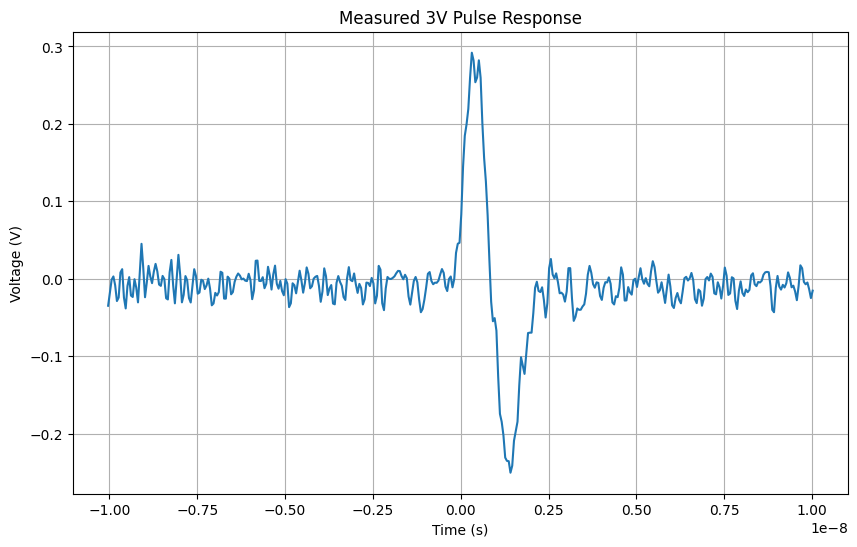


Saved measurement and metadata to: \\files22.brown.edu\Research\ENG_Caretta_Shared\Group\probe_station\AQ_027\ultrapulser022526\2_neg_40v_chan_3um_00.csv


In [94]:
# Prepare oscilloscope to wait for trigger
scope.arm()

# Turn AWG ON and trigger the pulse output
awg.output(channel=1, on=True)
awg.output_trigger()

start_time = time.time()
data_df = None
while time.time() - start_time < 20:
    try:
        data_df = scope.get_data(channel=1)
        if data_df is not None and not data_df.empty:
            break
    except Exception:
        pass
    time.sleep(0.1)

if data_df is None or data_df.empty:
    raise TimeoutError("Oscilloscope data acquisition timed out after 10 seconds.")

# Turn the output back off for safety after measurement
awg.output(channel=1, on=False)

# Give a quick plot to verify integrity
plt.figure(figsize=(10, 6))
plt.plot(data_df['Time'], data_df['Voltage'])
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Measured 3V Pulse Response")
plt.grid(True)
plt.show()

### Save Data to CSV ###
N += 1
# Create PIEC standard metadata dataframe to match data payload
metadata_df = pd.DataFrame({
    "Measurement Type": ["Single Pulse"],
    "Expected Pulse V": [3.0],
    "Expected Pulse Width": ["1us"],
    "npulse": [N]
})

# Generate incrementing filename without overwriting past data
filename = create_measurement_filename(
    directory=r"\\files22.brown.edu\Research\ENG_Caretta_Shared\Group\probe_station\AQ_027\ultrapulser022526", 
    measurement_type="neg_40v",
    notes="chan_3um_00"
)

# Convinience function that structures metadata cleanly above data
metadata_and_data_to_csv(metadata_df, data_df, filename)

print(f"\nSaved measurement and metadata to: {filename}")